# Sensitivity audit: stress model versus intuitive population model

This notebook asks whether the three synthetic discrepancies are robust mechanisms or artifacts of selected parameters.

It compares:

1. **The original stress model**, which uses independent campaign-level archetype opportunity and price shocks plus an explicit direction-specific cost contrast.
2. **The intuitive model**, which uses stable publisher activity rankings and named campaign profiles without campaign-specific latent-population shocks.

Two sweeps are reported:

- **One factor at a time:** turns each mechanism from absent to strong.
- **Joint combinations:** samples all parameters together. The wide regime includes null mechanisms; the active regime requires every proposed mechanism to be at least moderately present.

The desired behavior is not universal reproduction. If response rankings are identical, the Traffic gap should disappear. If publisher activity rankings are identical, the direction effect should disappear. If campaign profiles are identical, large-Reach dispersion should disappear.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    repo = Path("/content/calibrated-vid")
    if not repo.exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--branch", "main",
            "https://github.com/world-federation-of-advertisers/calibrated-vid.git",
            str(repo),
        ], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(repo)], check=True)
    os.chdir(repo)

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

In [2]:
import csv
import html
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import HTML, display

from calibrated_vid.sensitivity import run_sensitivity

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
OUTPUT = ROOT / "outputs" / "model_sensitivity"
report = run_sensitivity(OUTPUT)

def read_csv(path):
    with path.open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

one_factor = read_csv(OUTPUT / "one_factor_sweep.csv")
joint = read_csv(OUTPUT / "joint_sweep.csv")
summary = report["joint_summary"]

def show_table(rows, columns, digits=2):
    head = "".join(f"<th>{html.escape(label)}</th>" for _, label in columns)
    body = []
    for row in rows:
        cells = []
        for key, _ in columns:
            value = row[key]
            if isinstance(value, float):
                value = f"{value:.{digits}f}"
            cells.append(f"<td>{html.escape(str(value))}</td>")
        body.append("<tr>" + "".join(cells) + "</tr>")
    display(HTML("<table><thead><tr>" + head + "</tr></thead><tbody>" + "".join(body) + "</tbody></table>"))

summary

[{'model': 'stress',
  'regime': 'wide',
  'configurations': 48,
  'traffic_lower_share': 1.0,
  'positive_direction_share': 0.9583333333333334,
  'large_width_over_5_share': 0.9791666666666666,
  'all_qualitative_share': 0.9375,
  'all_material_share': 0.6041666666666666,
  'objective_gap_median': 29.49722222222222,
  'direction_gap_median': 8.133333333333335,
  'large_width_median': 34.76166666666667},
 {'model': 'stress',
  'regime': 'active',
  'configurations': 48,
  'traffic_lower_share': 1.0,
  'positive_direction_share': 1.0,
  'large_width_over_5_share': 1.0,
  'all_qualitative_share': 1.0,
  'all_material_share': 0.6875,
  'objective_gap_median': 29.5,
  'direction_gap_median': 9.5,
  'large_width_median': 36.31},
 {'model': 'intuitive',
  'regime': 'wide',
  'configurations': 48,
  'traffic_lower_share': 0.5833333333333334,
  'positive_direction_share': 0.9375,
  'large_width_over_5_share': 0.625,
  'all_qualitative_share': 0.4166666666666667,
  'all_material_share': 0.08333

## Intuitive model: each output follows its stated mechanism

The three panels are deliberate falsification checks:

- Publisher-specific response contrast should control the Traffic-versus-Reach gap.
- Publisher activity contrast should control size direction.
- Campaign-profile strength should control dispersion among equal-size large Reach campaigns.

Each point is the median across three independently generated synthetic markets. Bands show the minimum and maximum.

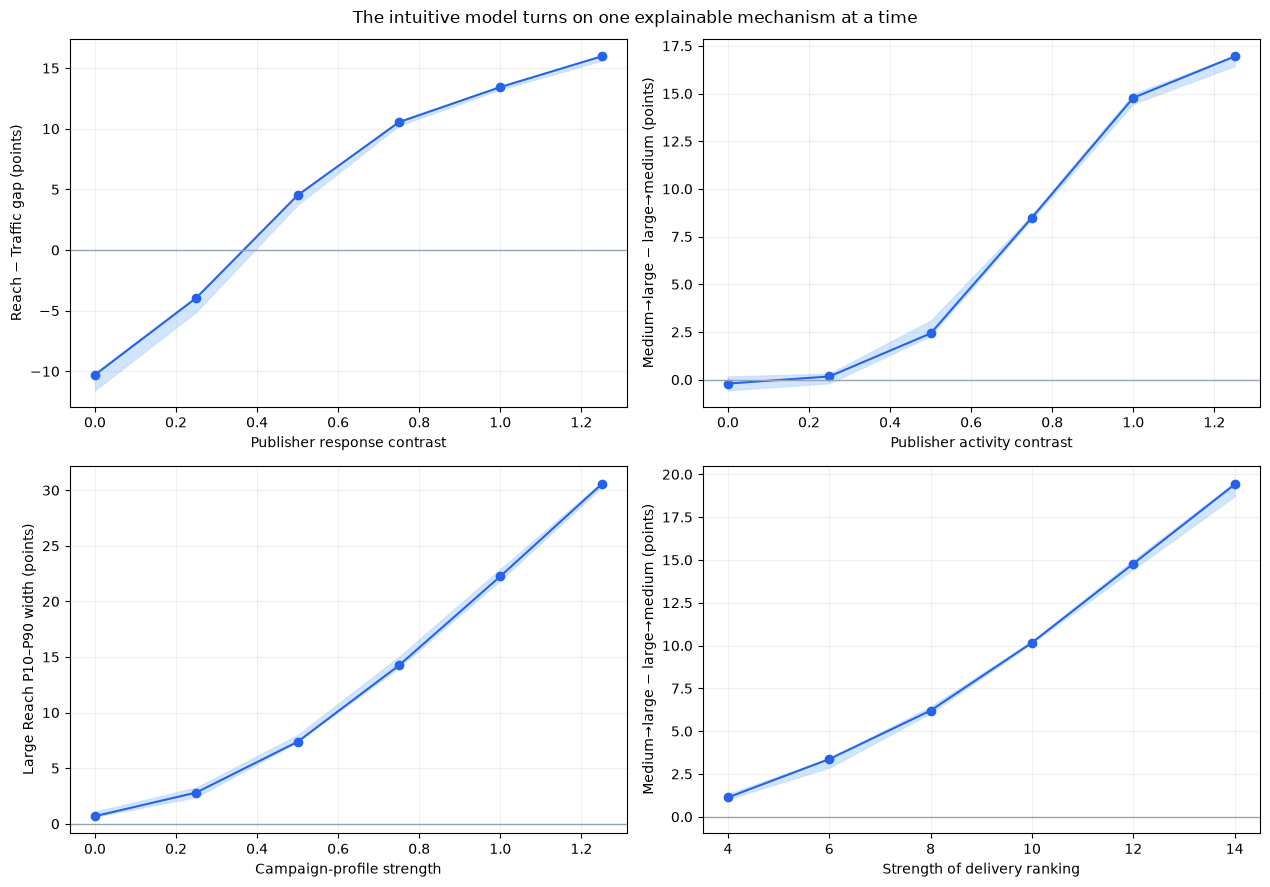

In [3]:
def curve(model, parameter, metric):
    rows = [row for row in one_factor if row["model"] == model and row["parameter"] == parameter]
    values = sorted({float(row["value"]) for row in rows})
    medians, lows, highs = [], [], []
    for value in values:
        measurements = [float(row[metric]) for row in rows if float(row["value"]) == value]
        medians.append(float(np.median(measurements)))
        lows.append(float(np.min(measurements)))
        highs.append(float(np.max(measurements)))
    return np.asarray(values), np.asarray(medians), np.asarray(lows), np.asarray(highs)

panels = [
    ("response_contrast", "objective_gap_points", "Publisher response contrast", "Reach − Traffic gap (points)"),
    ("activity_contrast", "direction_gap_points", "Publisher activity contrast", "Medium→large − large→medium (points)"),
    ("profile_strength", "large_reach_width_points", "Campaign-profile strength", "Large Reach P10–P90 width (points)"),
    ("selection_concentration", "direction_gap_points", "Strength of delivery ranking", "Medium→large − large→medium (points)"),
]
fig, axes = plt.subplots(2, 2, figsize=(12.8, 9.0))
for ax, (parameter, metric, xlabel, ylabel) in zip(axes.flat, panels):
    x, median, low, high = curve("intuitive", parameter, metric)
    ax.plot(x, median, marker="o", color="#2563eb")
    ax.fill_between(x, low, high, color="#bfdbfe", alpha=0.7)
    ax.axhline(0, color="#94a3b8", linewidth=1)
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.grid(alpha=0.18)
fig.suptitle("The intuitive model turns on one explainable mechanism at a time")
fig.tight_layout()
fig.savefig(OUTPUT / "intuitive_one_factor.png", dpi=180)
plt.show()

> **Interpretation.** These curves are the strongest reason to prefer the intuitive model. The direction effect is near zero when publisher activity orderings are identical. Large-Reach dispersion collapses when campaign profiles are identical. The objective result can reverse when the two publishers value the same responders, then becomes a Reach-over-Traffic gap as publisher-specific response selection strengthens. The model therefore does not force the requested conclusions under null conditions.

## Original stress model: broad shocks make the patterns easier to reproduce

The original model remains a useful possibility demonstration, but its outputs are harder to attribute. Opportunity and price shocks vary independently by campaign, and the direction test contains an explicit contrast designed to separate the two orientations.

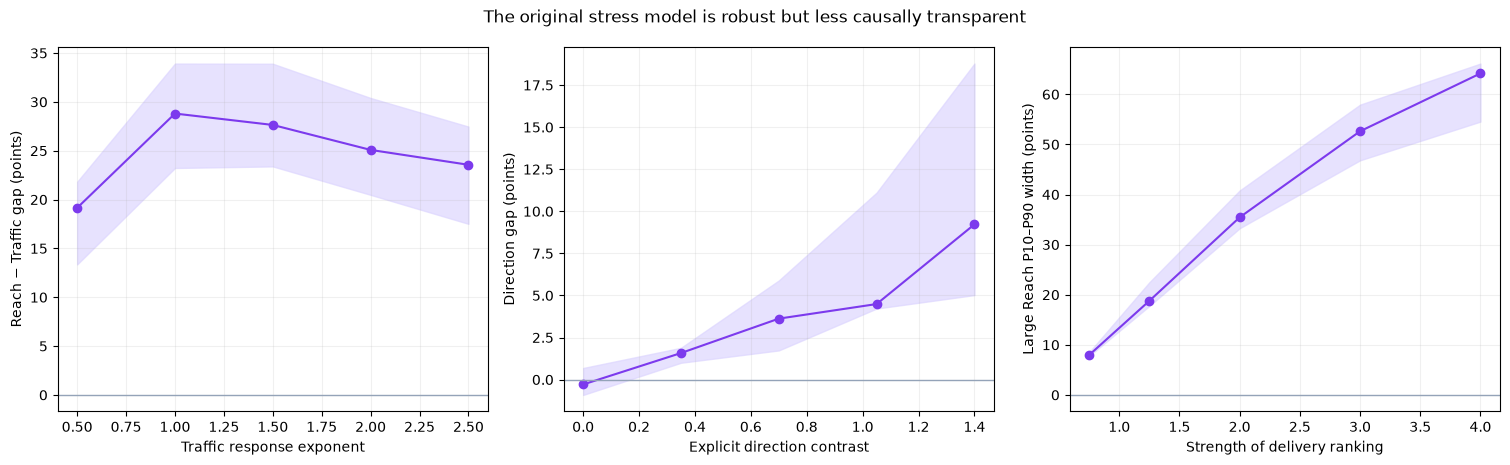

In [4]:
stress_panels = [
    ("traffic_response_exponent", "objective_gap_points", "Traffic response exponent", "Reach − Traffic gap (points)"),
    ("direction_cost_contrast", "direction_gap_points", "Explicit direction contrast", "Direction gap (points)"),
    ("selection_concentration", "large_reach_width_points", "Strength of delivery ranking", "Large Reach P10–P90 width (points)"),
]
fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.7))
for ax, (parameter, metric, xlabel, ylabel) in zip(axes, stress_panels):
    x, median, low, high = curve("stress", parameter, metric)
    ax.plot(x, median, marker="o", color="#7c3aed")
    ax.fill_between(x, low, high, color="#ddd6fe", alpha=0.7)
    ax.axhline(0, color="#94a3b8", linewidth=1)
    ax.set(xlabel=xlabel, ylabel=ylabel)
    ax.grid(alpha=0.18)
fig.suptitle("The original stress model is robust but less causally transparent")
fig.tight_layout()
fig.savefig(OUTPUT / "stress_one_factor.png", dpi=180)
plt.show()

## Joint sweep

“Qualitative” means Traffic overlap is lower, the configured direction gap is positive, and the large-Reach P10–P90 width exceeds five points.

“Material” uses deliberately stronger descriptive thresholds: objective gap above five points, direction gap above five points, and large-Reach width above ten points. These thresholds organize the synthetic results; they are not empirical standards.

Campaign-profile strength is supported from 0 through 1.25. At the upper boundary, the shortest 10-day profile still has two positive effective days; larger values are rejected rather than silently producing invalid negative durations.

In [5]:
display_rows = []
for row in summary:
    display_rows.append({
        "model": row["model"],
        "regime": row["regime"],
        "configurations": row["configurations"],
        "qualitative %": 100 * row["all_qualitative_share"],
        "material %": 100 * row["all_material_share"],
        "objective gap": row["objective_gap_median"],
        "direction gap": row["direction_gap_median"],
        "large width": row["large_width_median"],
    })
show_table(display_rows, [
    ("model", "Model"),
    ("regime", "Parameter regime"),
    ("configurations", "Configurations"),
    ("qualitative %", "All three qualitative %"),
    ("material %", "All three material %"),
    ("objective gap", "Median objective gap"),
    ("direction gap", "Median direction gap"),
    ("large width", "Median large-Reach width"),
])

Model,Parameter regime,Configurations,All three qualitative %,All three material %,Median objective gap,Median direction gap,Median large-Reach width
stress,wide,48,93.75,60.42,29.50,8.13,34.76
stress,active,48,100.00,68.75,29.50,9.50,36.31
intuitive,wide,48,41.67,8.33,8.43,2.30,7.22
intuitive,active,48,100.00,75.00,14.09,9.10,16.55


## What I conclude

1. **The original stress notebook is robust but overpowered.** Its broad latent opportunity and price shocks make large dispersion common, while its explicit direction contrast makes the directional result relatively easy to obtain. It is useful as a stress test but not the clearest primary explanation.
2. **The intuitive notebook is more falsifiable.** Across a deliberately wide range that includes absent mechanisms, all three patterns need not appear—and they should not. Each output approaches zero or changes sign when its proposed cause is removed.
3. **When the intuitive mechanisms are active, the patterns become materially more common.** This is stronger evidence of internal coherence than forcing every parameter combination to reproduce the headline.
4. **Size direction is the most conditional result.** It needs meaningful publisher activity asymmetry and sufficiently ranked selection. Objective differences and profile-driven large-Reach dispersion arise across a broader set of active configurations.

The intuitive notebook should replace the stress notebook as the primary explanation. The stress notebook should remain labeled as an illustrative stress test. Neither notebook estimates real-world magnitudes or proves the cause of any production result.